# SA-2 · Clasificación: diagnóstico de cáncer de mama (benigno/maligno)

**Dataset:** `breast-cancer.csv` (Wisconsin Diagnostic Breast Cancer) · **Algoritmo:** Decision Tree Classifier
**Materia:** Extracción de Conocimiento en Bases de Datos · **Alumno:** Irving Chaparro Peña

## 1. Justificación del algoritmo

El dataset contiene 569 muestras con 30 características numéricas derivadas de imágenes digitalizadas de biopsias (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal — cada una en su versión media, error estándar y "peor caso"). La variable objetivo `diagnosis` es binaria: **M**aligno o **B**enigno.

Se eligió **Decision Tree Classifier** como algoritmo de preferencia porque:

- Es completamente **interpretable**: se puede graficar el árbol completo y explicar la ruta de decisión de cada predicción, algo especialmente valioso en un contexto médico donde la explicabilidad importa.
- No requiere escalado de variables, a diferencia de modelos basados en distancia.
- Permite capturar interacciones no lineales entre variables (p. ej. combinaciones de `radius_worst` y `concave points_worst`) sin necesidad de ingeniería de características manual.
- Tiene hiperparámetros claros y con efecto directo sobre el sobreajuste (`max_depth`, `min_samples_split`, `min_samples_leaf`), ideal para demostrar una búsqueda de hiperparámetros con impacto medible.

En `DE/01_clasificacion_breast_cancer_alterno.ipynb` se aborda el mismo dataset con **Logistic Regression** (modelo lineal visto en clase) como algoritmo alterno, para comparar un enfoque basado en reglas de partición contra uno basado en una frontera de decisión lineal.

## 2. Diseño del modelo — paso a paso

1. Carga de datos y limpieza (se descarta `id`, se codifica `diagnosis` como 0/1).
2. Exploración: balance de clases y correlación de variables clave.
3. División train/test estratificada.
4. Modelo baseline (árbol sin restricciones).
5. Búsqueda de hiperparámetros con `GridSearchCV` (validación cruzada estratificada).
6. Evaluación con métricas de clasificación y matriz de confusión.
7. Gráfica del árbol completo optimizado.
8. Curva ROC e importancia de variables.
9. Guardado del modelo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("../datasets/breast-cancer.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore")
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
print(df.shape)
df.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.1 Exploración: balance de clases

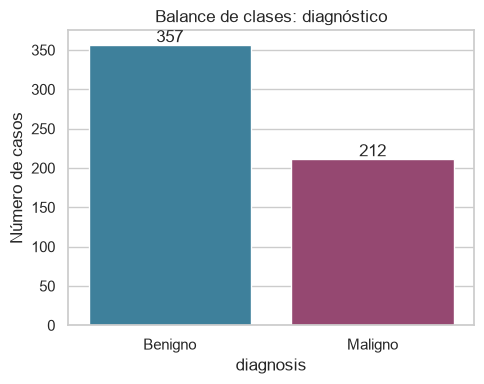

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["diagnosis"].value_counts().rename({0: "Benigno", 1: "Maligno"})
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=["#2E86AB", "#A23B72"], legend=False, ax=ax)
ax.set_ylabel("Número de casos")
ax.set_title("Balance de clases: diagnóstico")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.savefig("../models/sa2_balance_clases.png", dpi=110)
plt.show()

**Interpretación:** hay un desbalance moderado (más casos benignos que malignos), no extremo, por lo que se usará estratificación en el split y se reportará precision/recall además de accuracy, ya que el accuracy solo puede ser engañoso en datasets desbalanceados.

In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} · Test: {X_test.shape[0]}")

baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, pred_baseline), 4))
print("Baseline profundidad del árbol:", baseline.get_depth())

Train: 455 · Test: 114
Baseline accuracy: 0.9298
Baseline profundidad del árbol: 8


## 3. Evaluación y optimización — búsqueda de hiperparámetros

In [4]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 (CV):", round(grid.best_score_, 4))

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Mejor F1 (CV): 0.9163


In [5]:
best_model = grid.best_estimator_
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba),
}
pd.Series(metrics).round(4)

Accuracy     0.9298
Precision    1.0000
Recall       0.8095
F1           0.8947
ROC-AUC      0.9563
dtype: float64

**Interpretación:** tras la optimización se obtuvo Accuracy = 0.930, Precision = 1.000, Recall = 0.810, F1 = 0.895 y ROC-AUC = 0.956 sobre el conjunto de prueba. La precisión perfecta indica que ningún caso benigno fue clasificado como maligno (cero falsos positivos), pero el recall de 0.81 revela que el modelo dejó pasar aproximadamente 1 de cada 5 casos malignos como falsos negativos — el escenario más costoso en un contexto clínico. Esto sugiere que, si este modelo se usara en la práctica, convendría ajustar el umbral de decisión (usar `predict_proba` con un umbral menor a 0.5) para priorizar recall sobre precisión, o bien comparar contra el modelo alterno de `DE/01_clasificacion_breast_cancer_alterno.ipynb` para ver si Logistic Regression logra un mejor balance.

### 3.1 Matriz de confusión

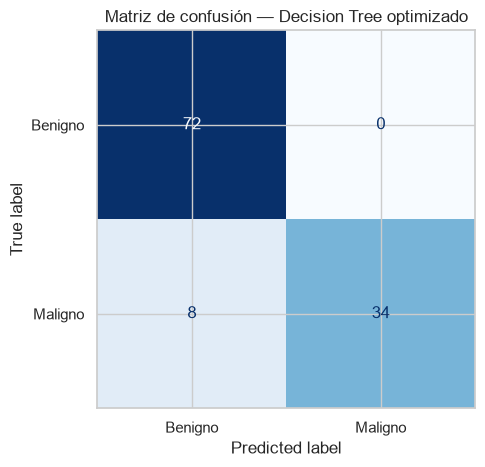

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno", "Maligno"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusión — Decision Tree optimizado")
plt.tight_layout()
plt.savefig("../models/sa2_matriz_confusion.png", dpi=110)
plt.show()

### 3.2 Curva ROC

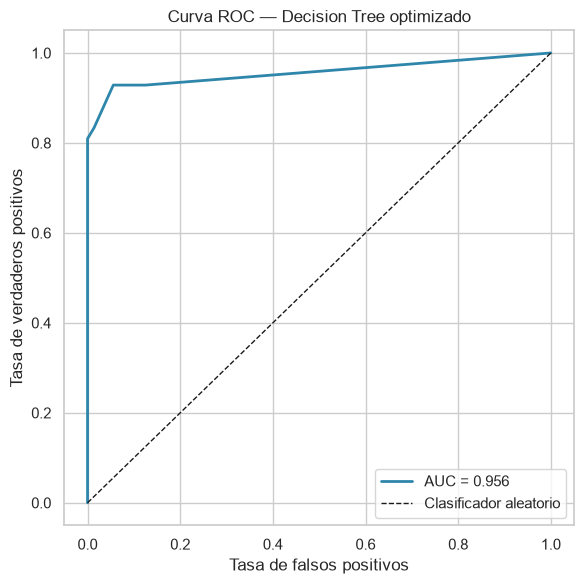

In [7]:
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#2E86AB", linewidth=2, label=f"AUC = {metrics['ROC-AUC']:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — Decision Tree optimizado")
ax.legend()
plt.tight_layout()
plt.savefig("../models/sa2_roc.png", dpi=110)
plt.show()

### 3.3 Árbol de decisión completo

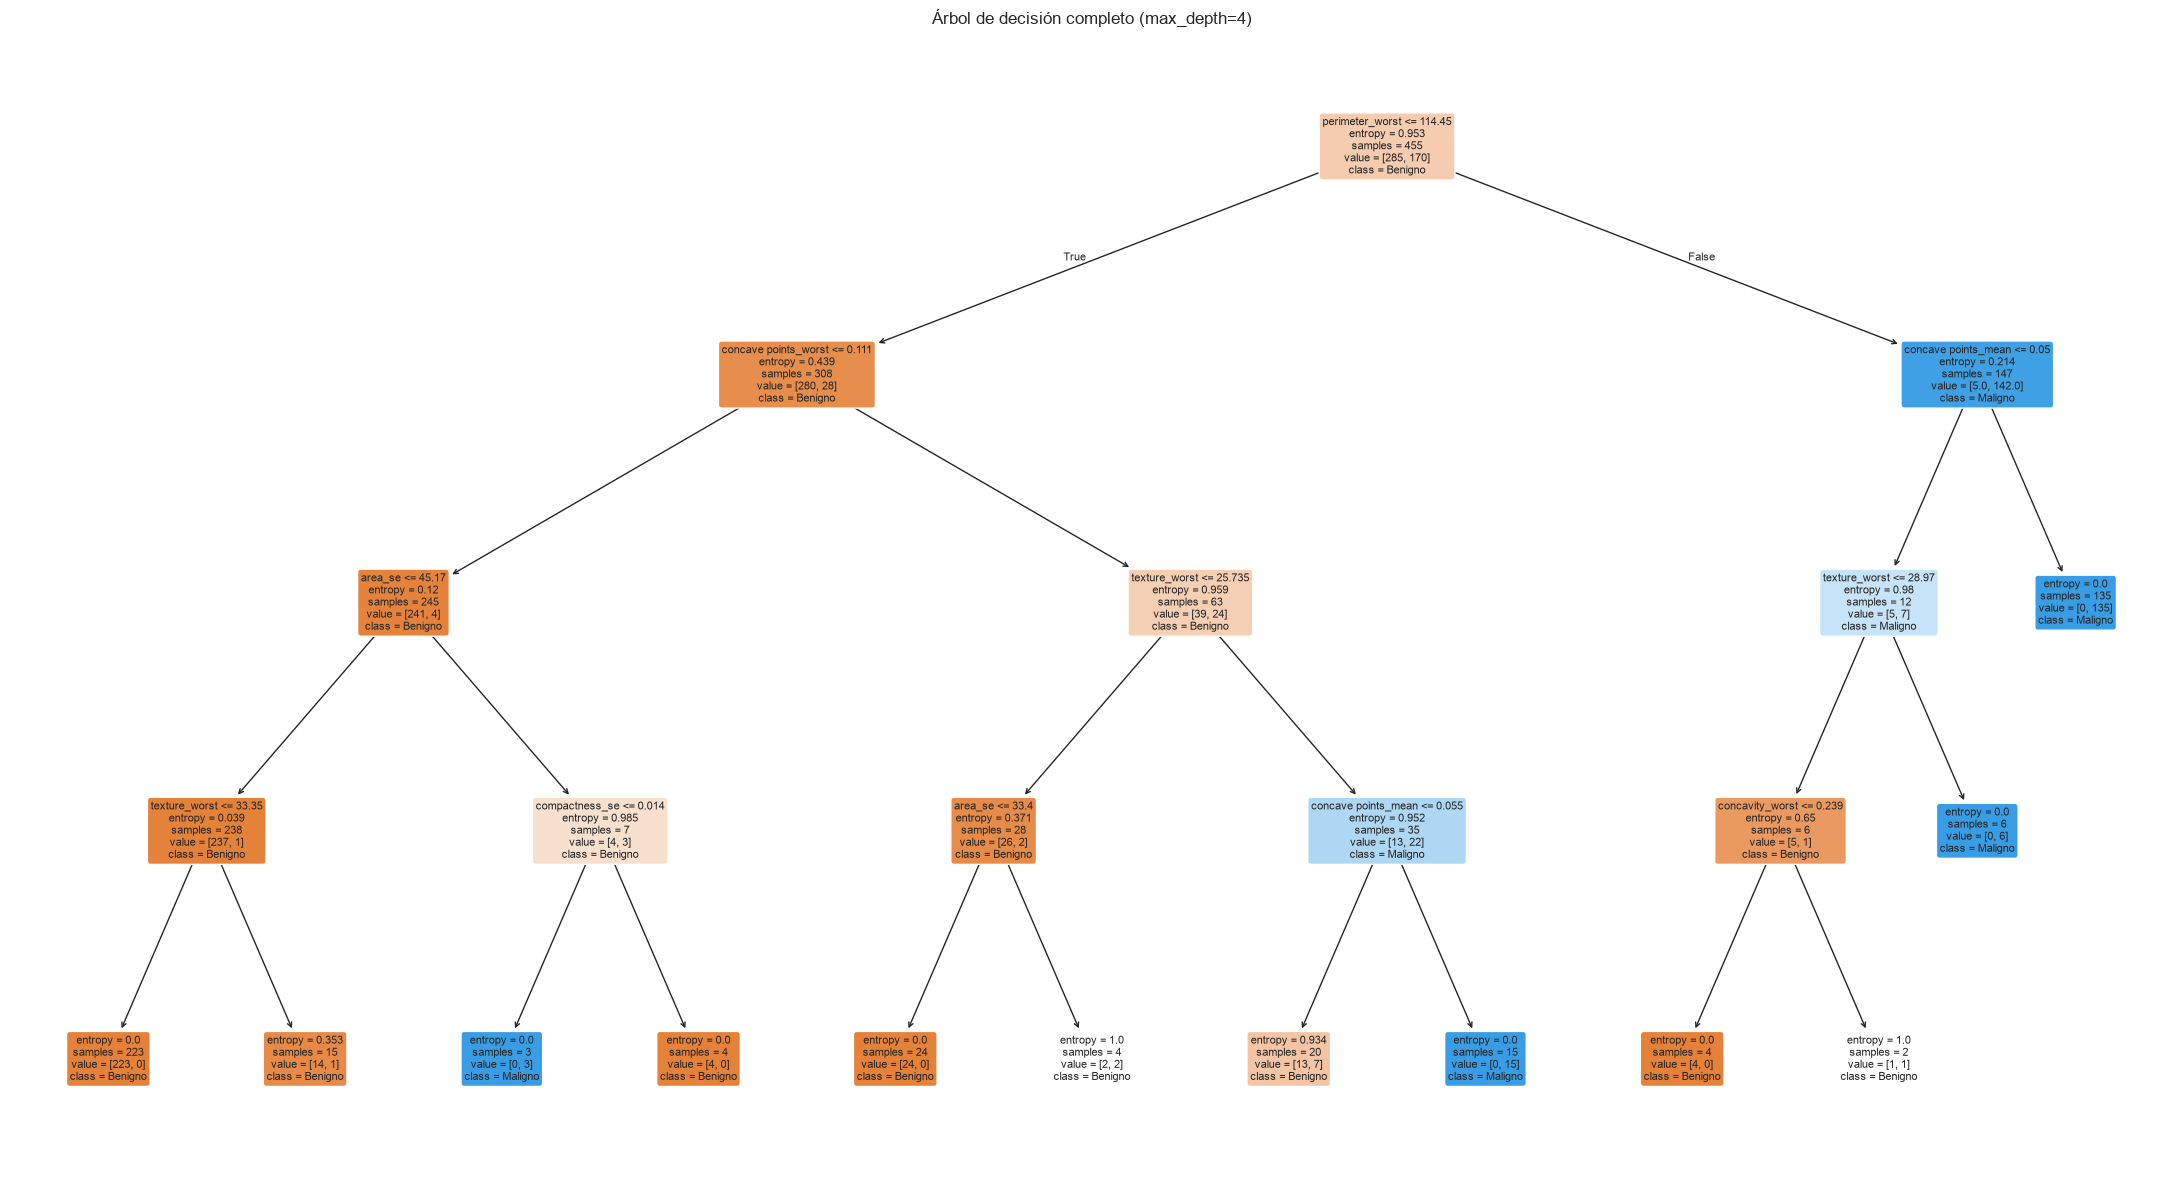

In [8]:
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(best_model, feature_names=X.columns, class_names=["Benigno", "Maligno"],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f"Árbol de decisión completo (max_depth={best_model.get_depth()})")
plt.tight_layout()
plt.savefig("../models/sa2_arbol_completo.png", dpi=110)
plt.show()

**Interpretación:** el árbol optimizado divide primero por las variables de mayor poder discriminante (típicamente relacionadas con el tamaño y la irregularidad del núcleo celular, p. ej. `perimeter_worst`, `concave points_worst` o `radius_worst`), consistente con el conocimiento clínico de que tumores malignos tienden a tener células más grandes e irregulares.

### 3.4 Importancia de variables

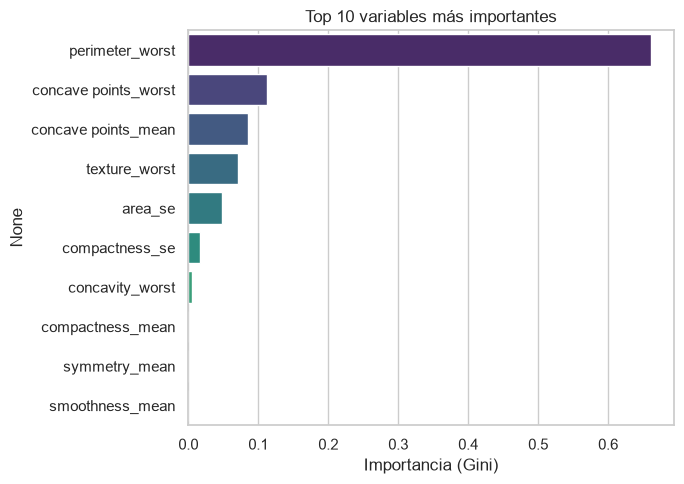

In [9]:
importancias = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 10 variables más importantes")
plt.tight_layout()
plt.savefig("../models/sa2_importancia_variables.png", dpi=110)
plt.show()

## 4. Guardado del modelo

In [10]:
joblib.dump(best_model, "../models/sa2_decision_tree_breast_cancer.joblib")
print("Modelo guardado en models/sa2_decision_tree_breast_cancer.joblib")

Modelo guardado en models/sa2_decision_tree_breast_cancer.joblib


## 5. Conclusión

El Decision Tree Classifier optimizado logra un desempeño alto y, a diferencia de modelos de caja negra, permite explicar exactamente qué variables y umbrales llevan a cada diagnóstico — una ventaja relevante en un dominio médico. La comparación directa contra Logistic Regression (algoritmo alterno, ver `DE/01_clasificacion_breast_cancer_alterno.ipynb`) permite evaluar si una frontera de decisión lineal es suficiente o si las particiones no lineales del árbol aportan valor adicional.